# Glacier Hydraulic Tremor
This notebook starts the identification of glacier hydraulic tremor at Eqalorutsit Kangilliit Sermiat (Qajuuttap Sermia). We have 3 seismometers installed: QJT01, QJT02, QJT03 with the components 'HHZ','HHN','HHE' for the vertical, north, and east component of each seismometer. The sampling frequency is 200Hz.

In [2]:
import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import matplotlib
import datetime
import obspy
import seaborn as sns
import math
import datetime
from obspy import UTCDateTime
from obspy.clients.filesystem.sds import Client
from multiprocessing import Pool
import statsmodels.api as sm
import statsmodels.formula.api as smf

## Week 20

In [3]:
times = np.load("results_all_z\\0.npz", allow_pickle = True)["times"]
GHTs = np.load("results_all_z\\0.npz", allow_pickle = True)["GHT"]
for i in range(1, 325):
    times = np.hstack((times, np.load("results_all_z\\" + str(i) + ".npz", allow_pickle = True)["times"]))
    GHTs = np.dstack((GHTs, np.load("results_all_z\\" + str(i) + ".npz", allow_pickle = True)["GHT"]))
    print(str(i), end = '\r')

times = times[0]
np.shape(GHTs)
np.shape(times)
# GHTs

(46800,)

In [4]:
freqbounds = [(1, 4), (4, 7), (7, 10)]
stations = ['QJT01', 'QJT02', 'QJT03']

# Calculate mean GHT between stations
df_list = []

# Put GHT data into DataFrames
for idx1, freqbound in enumerate(freqbounds):
    for idx2, station in enumerate(stations):
      t = times.copy()
      GHT = GHTs[idx1, idx2, :].copy()
      print(np.shape(GHT))
      print(np.shape(t))
      df = pd.DataFrame(data=GHT, index=t, columns = [(freqbound, station)])
      df_alt = df.iloc[:-2] 
      df_list.append(df)

# Merge the three DataFrames into a single one
df_ght = pd.concat(df_list, axis='columns')

# Normalization
df_ght = df_ght.divide(df_ght.median(skipna=True))

# Rolling averaging for each station
df_ght = df_ght.rolling('6h', center=True).median()

df_ght.iloc[:, [0, 3, 6]] = df_ght.iloc[:, [0, 3, 6]] / df_ght.iloc[:, [0, 3, 6]].sum().sum()

df_ght.iloc[:, [1, 4, 7]] = df_ght.iloc[:, [1, 4, 7]] / df_ght.iloc[:, [1, 4, 7]].sum().sum()

df_ght.iloc[:, [2, 5, 8]] = df_ght.iloc[:, [2, 5, 8]] / df_ght.iloc[:, [2, 5, 8]].sum().sum()

# Mean between stations
df_ght['mean'] = df_ght.mean(axis='columns')

# Setting GHT relative to minimum power
df_ght = df_ght / np.nanmin(df_ght['mean'])

# Standard Deviation
df_ght['std'] = df_ght[:-1].std(axis='columns')

df_ght['mean14'] = df_ght.iloc[:, 0:3].mean(axis='columns')
df_ght['std14'] = df_ght.iloc[:, 0:3].std(axis='columns')
df_ght['mean47'] = df_ght.iloc[:, 3:6].mean(axis='columns')
df_ght['std47'] = df_ght.iloc[:, 3:6].std(axis='columns')
df_ght['mean710'] = df_ght.iloc[:, 6:9].mean(axis='columns')
df_ght['std710'] = df_ght.iloc[:, 6:9].std(axis='columns')
# # df_ght[reference_ght_loc]
# reference_ght_loc

# fig, ax = plt.subplots()
# ax.plot(df_ght.index, df_ght["mean"])

df_ght

(46800,)
(46800,)
(46800,)
(46800,)
(46800,)
(46800,)
(46800,)
(46800,)
(46800,)
(46800,)
(46800,)
(46800,)
(46800,)
(46800,)
(46800,)
(46800,)
(46800,)
(46800,)


,"((1, 4), QJT01)","((1, 4), QJT02)","((1, 4), QJT03)","((4, 7), QJT01)","((4, 7), QJT02)","((4, 7), QJT03)","((7, 10), QJT01)","((7, 10), QJT02)","((7, 10), QJT03)",mean,std,mean14,std14,mean47,std47,mean710,std710
2023-09-01 00:05:00,7.681763,8.793049,9.017484,15.665616,8.386420,12.475420,13.153737,6.036028,7.567744,9.864140,2.982089,8.497432,0.715248,12.175819,3.648834,8.919170,3.746359
2023-09-01 00:15:00,7.415883,8.643044,9.042683,15.701794,8.139925,12.485180,13.249616,5.747814,7.574471,9.777823,3.085124,8.367203,0.847753,12.108966,3.794946,8.857300,3.911968
2023-09-01 00:25:00,7.681763,8.793049,9.067883,15.737972,7.893429,12.494941,13.345494,6.036028,7.581199,9.847973,3.052039,8.514231,0.733918,12.042114,3.941827,8.987574,3.852336
2023-09-01 00:35:00,7.743883,8.808657,9.217626,15.701794,7.746157,12.557813,13.367867,6.045065,7.606318,9.866131,3.051532,8.590056,0.760802,12.001921,4.006844,9.006417,3.856950
2023-09-01 00:45:00,7.806003,8.824265,9.367370,15.737972,7.598885,12.620684,13.390240,6.054102,7.631437,9.892329,3.068178,8.665880,0.792642,11.985847,4.106513,9.025260,3.861579
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-21 23:15:00,27.516389,27.536215,42.398508,25.329194,12.956130,25.650760,11.579871,8.015689,8.811837,21.088288,10.821631,32.483704,8.586478,21.312028,7.238206,9.469132,1.870796
2024-07-21 23:25:00,27.732173,25.550080,41.256393,24.480824,12.968641,27.005235,11.841594,8.045159,8.912323,20.865825,10.470502,31.512882,8.508371,21.484900,7.482524,9.599692,1.989369
2024-07-21 23:35:00,27.325996,27.073197,42.398508,25.051968,13.377608,28.007868,12.099879,8.015689,9.015423,21.374015,10.794048,32.265901,8.776006,22.145815,7.735982,9.710330,2.128926
2024-07-21 23:45:00,27.732173,29.522350,43.540624,26.177564,12.968641,27.005235,11.841594,7.986219,8.912323,21.742969,11.292986,33.598382,8.656634,22.050480,7.875983,9.580045,2.012553


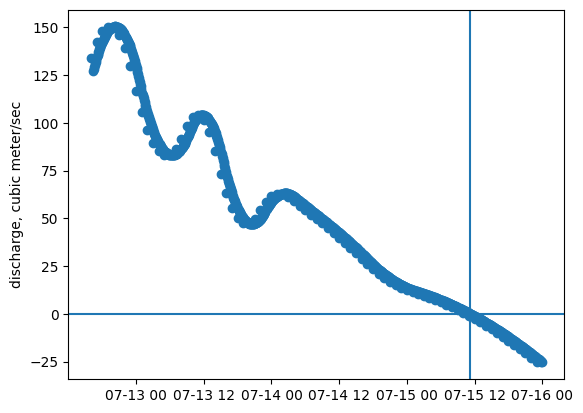

In [5]:
x = [12.614744365941817, 12.814506764288078, 13.028537672098178, 13.399524143522024, 13.642092723430304, 13.947800029240266, 14.170035411638388, 14.417598133151635, 14.721521630339682, 15.066825437899109, 15.508799131892868, 16.00642099255135, 16.407015682514725, 16.75231818373316, 17.351961356691724, 17.837098516508284, 18.35077269525253, 20.6195003180396, 18.878716036631108, 19.806182868361216, 19.363851890106677, 21.161711515711527, 21.71819187601779, 22.27467223632405, 22.873958778192335, 23.673008371577374, 24.70035672906586, 25.22829876410345, 25.71343592392001]
y = [150.95890410958904, 149.58904318613548, 148.01369967525952, 146.23287671232876, 145, 144.1215765966128, 143.42465962449165, 142.7294545630886, 142.13185036019104, 141.8013700720382, 141.66780968234966, 142.00000188122058, 142.7294545630886, 143.52568743980095, 145, 146.23287671232876, 147.32876921353275, 152.05479661079303, 148.35616647380672, 150.41096099435467, 149.4520558396431, 153.082193871067, 154.17808323690335, 155.20548049717735, 156.0958904109589, 157.1917829121629, 158.49315173005405, 158.97260273972603, 159.17808219178082]
pairs = sorted(list(zip(x,y)), key = lambda pair: pair[0])
x = [pair[0] for pair in pairs]
y = [- 5000000 * pair[1] / 3 for pair in pairs]
time_int = 300 / 60 / 60 / 24 # 300 seconds

xs_finals = []
# 12th, 16:21:55
start = 12 + 16/24 + 25/(24*60) 
curr = start
while curr < 16:
    xs_finals.append(curr)
    curr += time_int

volume_time_curve = scipy.interpolate.CubicSpline(x, y)
ys_finals = volume_time_curve.derivative()(xs_finals)

pairs = np.array(list(zip(xs_finals, ys_finals)))
# pairs = pairs[pairs[:,1] > 0]
xs_finals  = pairs[:,0]

xs_finals = [datetime.datetime(year = 2024, 
                        month = 7, 
                        day = int(x // 1), 
                        hour = int((x % 1 * 24) // 1),
                        minute = round(((x % 1 * 24) % 1 * 60)) % 60,
                        second = 0) for x in xs_finals]

ys_finals = pairs[:,1]
ys_finals /= 86400 # scales the discharge to m^3s^(-1)

fig, ax = plt.subplots()
ax.scatter(xs_finals, ys_finals)
ax.set_ylabel("discharge, cubic meter/sec")
ax.axvline(x = datetime.datetime(year = 2024, month = 7, day = 15, hour = 11, minute = 15, second = 33))
ax.axhline(y = 0)

discharge = dict(zip(xs_finals, ys_finals))



int(volume_time_curve.derivative().roots()[1] // 1)
(volume_time_curve.derivative().roots()[1] % 1) * 24 # 11
(volume_time_curve.derivative().roots()[1] % 1) * 24 % 1 * 60 # 15
(volume_time_curve.derivative().roots()[1] % 1) * 24 % 1 * 60 % 1 * 60 # 33

ref_date = datetime.datetime(year = 2024, month = 7, day = 15, hour = 11, minute = 15)
ref_date = np.datetime64(ref_date)

(np.float64(19916.0), np.float64(19920.0))

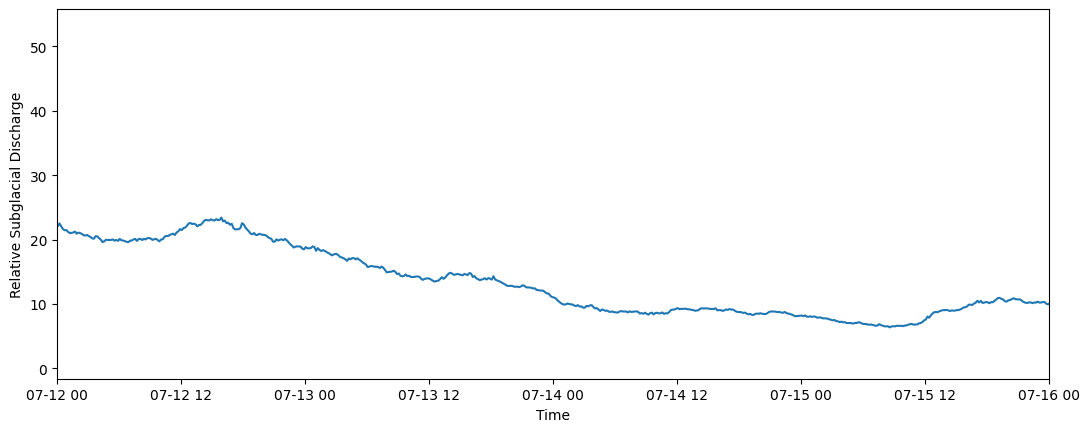

In [6]:
fig = plt.figure(figsize=(2*6.4,4.8))

plt.plot(df_ght.index, np.power(df_ght["mean"], 4/5))
plt.ylabel('Relative Subglacial Discharge')
plt.xlabel('Time')
plt.xlim(np.datetime64('2024-07-12'), np.datetime64('2024-07-16'))


In [7]:
# df_ght["discharge"] = df_ght.index.to_series().apply(lambda x: discharge[pd.to_datetime(x).to_pydatetime()])
# df_ght[0]
trimmed_df_ght = df_ght[(df_ght.index < datetime.datetime(2024, 7, 16)) & (df_ght.index > datetime.datetime(2024, 7, 12, 16, 20))]
trimmed_df_ght["discharge"] = trimmed_df_ght.index.to_series().apply(lambda x: discharge[pd.to_datetime(x).to_pydatetime()])
# ref_power = trimmed_df_ght.iloc[-77,:]["mean"]
trimmed_df_ght


C:\Users\Admin\AppData\Local\Temp\ipykernel_113524\563770424.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trimmed_df_ght["discharge"] = trimmed_df_ght.index.to_series().apply(lambda x: discharge[pd.to_datetime(x).to_pydatetime()])


,"((1, 4), QJT01)","((1, 4), QJT02)","((1, 4), QJT03)","((4, 7), QJT01)","((4, 7), QJT02)","((4, 7), QJT03)","((7, 10), QJT01)","((7, 10), QJT02)","((7, 10), QJT03)",mean,std,mean14,std14,mean47,std47,mean710,std710,discharge
2024-07-12 16:25:00,73.167537,61.785572,92.423968,57.337649,33.566268,78.051534,17.446162,11.858078,16.694992,49.147973,28.291093,75.792359,15.486933,56.318484,22.260138,15.333077,3.032784,127.307053
2024-07-12 16:35:00,73.167537,59.707109,92.423968,60.527755,33.566268,78.051534,17.623493,11.858078,16.694992,49.291193,28.296627,75.099538,16.443773,57.381853,22.408865,15.392187,3.095639,129.246246
2024-07-12 16:45:00,71.772126,58.039034,92.423968,60.527755,33.137320,73.996459,17.623493,11.858078,16.694992,48.452580,27.689099,74.078376,17.308091,55.887178,20.821108,15.392187,3.095639,131.100396
2024-07-12 16:55:00,70.456896,58.039034,92.423968,60.527755,32.878200,79.471590,17.623493,11.858078,16.694992,48.886001,28.198832,73.639966,17.412061,57.625848,23.431854,15.392187,3.095639,132.869505
2024-07-12 17:05:00,66.129760,57.649430,91.655067,56.220261,32.560929,73.996459,17.446162,11.489840,16.074097,47.024667,27.052518,71.811419,17.700474,54.259216,20.787257,15.003366,3.119181,134.553571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-15 23:15:00,28.700453,22.875994,35.491889,20.273155,11.209351,25.643289,7.460094,6.186691,6.765972,18.289654,10.165483,29.022779,6.314120,19.041932,7.295312,6.804252,0.637564,-23.679158
2024-07-15 23:25:00,28.700453,22.875994,35.491889,20.273155,11.209351,27.118318,7.460094,6.162126,6.741693,18.448119,10.300119,29.022779,6.314120,19.533608,7.980226,6.787971,0.650220,-24.077726
2024-07-15 23:35:00,28.700453,22.875994,35.491889,20.273155,11.209351,27.118318,7.460094,6.225481,6.587909,18.438071,10.311281,29.022779,6.314120,19.533608,7.980226,6.757828,0.634604,-24.478197
2024-07-15 23:45:00,27.680718,22.337140,34.457516,18.836050,10.212082,27.118318,7.460094,6.162126,6.295432,17.839942,10.087740,28.158458,6.074295,18.722150,8.453694,6.639217,0.714018,-24.880573


,"((1, 4), QJT01)","((1, 4), QJT02)","((1, 4), QJT03)","((4, 7), QJT01)","((4, 7), QJT02)","((4, 7), QJT03)","((7, 10), QJT01)","((7, 10), QJT02)","((7, 10), QJT03)",mean,std,mean14,std14,mean47,std47,mean710,std710,discharge
2024-07-12 16:25:00,73.167537,61.785572,92.423968,57.337649,33.566268,78.051534,17.446162,11.858078,16.694992,49.147973,28.291093,75.792359,15.486933,56.318484,22.260138,15.333077,3.032784,127.307053
2024-07-12 16:35:00,73.167537,59.707109,92.423968,60.527755,33.566268,78.051534,17.623493,11.858078,16.694992,49.291193,28.296627,75.099538,16.443773,57.381853,22.408865,15.392187,3.095639,129.246246
2024-07-12 16:45:00,71.772126,58.039034,92.423968,60.527755,33.137320,73.996459,17.623493,11.858078,16.694992,48.452580,27.689099,74.078376,17.308091,55.887178,20.821108,15.392187,3.095639,131.100396
2024-07-12 16:55:00,70.456896,58.039034,92.423968,60.527755,32.878200,79.471590,17.623493,11.858078,16.694992,48.886001,28.198832,73.639966,17.412061,57.625848,23.431854,15.392187,3.095639,132.869505
2024-07-12 17:05:00,66.129760,57.649430,91.655067,56.220261,32.560929,73.996459,17.446162,11.489840,16.074097,47.024667,27.052518,71.811419,17.700474,54.259216,20.787257,15.003366,3.119181,134.553571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-15 23:15:00,28.700453,22.875994,35.491889,20.273155,11.209351,25.643289,7.460094,6.186691,6.765972,18.289654,10.165483,29.022779,6.314120,19.041932,7.295312,6.804252,0.637564,-23.679158
2024-07-15 23:25:00,28.700453,22.875994,35.491889,20.273155,11.209351,27.118318,7.460094,6.162126,6.741693,18.448119,10.300119,29.022779,6.314120,19.533608,7.980226,6.787971,0.650220,-24.077726
2024-07-15 23:35:00,28.700453,22.875994,35.491889,20.273155,11.209351,27.118318,7.460094,6.225481,6.587909,18.438071,10.311281,29.022779,6.314120,19.533608,7.980226,6.757828,0.634604,-24.478197
2024-07-15 23:45:00,27.680718,22.337140,34.457516,18.836050,10.212082,27.118318,7.460094,6.162126,6.295432,17.839942,10.087740,28.158458,6.074295,18.722150,8.453694,6.639217,0.714018,-24.880573


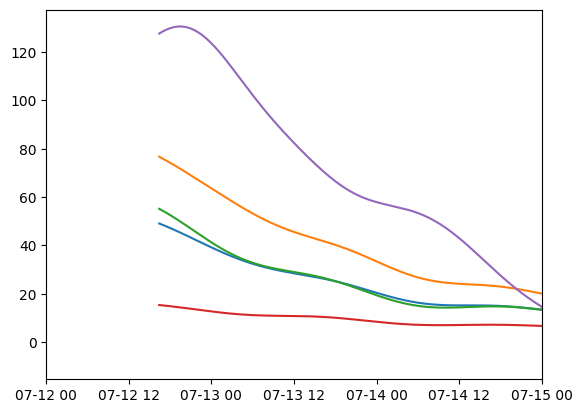

In [8]:
sos = scipy.signal.butter(4, 1/(86400), 'lp', fs = 1/600, output = 'sos')
filtered_tremor = scipy.signal.sosfiltfilt(sos, trimmed_df_ght["mean"])
filtered_tremor14 = scipy.signal.sosfiltfilt(sos, trimmed_df_ght["mean14"])
filtered_tremor47 = scipy.signal.sosfiltfilt(sos, trimmed_df_ght["mean47"])
filtered_tremor710 = scipy.signal.sosfiltfilt(sos, trimmed_df_ght["mean710"])
filtered_discharge = scipy.signal.sosfiltfilt(sos, trimmed_df_ght["discharge"])

# plt.plot(trimmed_df_ght.index, trimmed_df_ght["mean"])
plt.plot(trimmed_df_ght.index, filtered_tremor)
plt.plot(trimmed_df_ght.index, filtered_tremor14)
plt.plot(trimmed_df_ght.index, filtered_tremor47)
plt.plot(trimmed_df_ght.index, filtered_tremor710)
plt.plot(trimmed_df_ght.index, filtered_discharge)
plt.xlim(np.datetime64('2024-07-12'), np.datetime64('2024-07-15'))
trimmed_df_ght

C:\Users\Admin\AppData\Local\Temp\ipykernel_113524\3392648921.py:4: RuntimeWarning: invalid value encountered in log
  ax.scatter(np.log(filtered_tremor), np.log(filtered_discharge))


np.float64(-2.609015225308812)

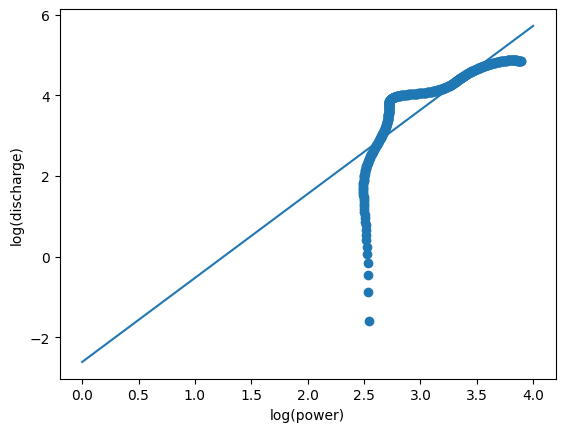

In [9]:
more_trimmed_df_ght = trimmed_df_ght[trimmed_df_ght["discharge"] > 0]

fig, ax = plt.subplots()
ax.scatter(np.log(filtered_tremor), np.log(filtered_discharge))
ax.set_xlabel("log(power)")
ax.set_ylabel("log(discharge)")
model_find_slope = scipy.stats.linregress(np.log(more_trimmed_df_ght["mean"]), np.log(more_trimmed_df_ght["discharge"]))
model_find_slope14 = scipy.stats.linregress(np.log(more_trimmed_df_ght["mean14"]), np.log(more_trimmed_df_ght["discharge"]))
model_find_slope47 = scipy.stats.linregress(np.log(more_trimmed_df_ght["mean47"]), np.log(more_trimmed_df_ght["discharge"]))
model_find_slope710 = scipy.stats.linregress(np.log(more_trimmed_df_ght["mean710"]), np.log(more_trimmed_df_ght["discharge"]))
plt.plot(range(5), model_find_slope.intercept + model_find_slope.slope * range(5))
power = model_find_slope.slope
power14 = model_find_slope14.slope
power47 = model_find_slope47.slope
power710 = model_find_slope710.slope
power
model_find_slope.intercept

np.float64(0.052912176039383085)

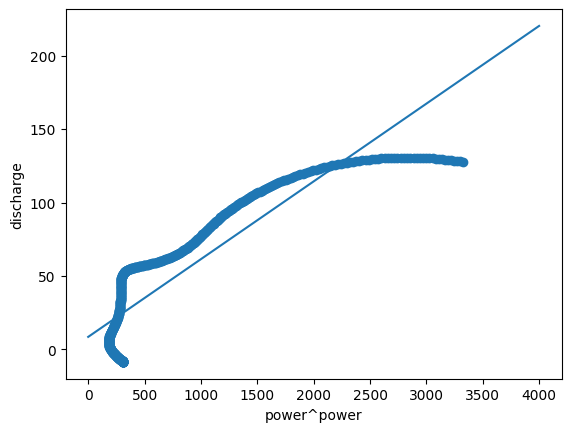

In [10]:
fig, ax = plt.subplots()
ax.scatter(np.power(filtered_tremor, power), filtered_discharge)
ax.set_xlabel("power^power")
ax.set_ylabel("discharge")
model_own_power = scipy.stats.linregress(np.power(trimmed_df_ght["mean"], power), trimmed_df_ght["discharge"])
model_own_power14 = scipy.stats.linregress(np.power(trimmed_df_ght["mean14"], power14), trimmed_df_ght["discharge"])
model_own_power47 = scipy.stats.linregress(np.power(trimmed_df_ght["mean47"], power47), trimmed_df_ght["discharge"])
model_own_power710 = scipy.stats.linregress(np.power(trimmed_df_ght["mean710"], power710), trimmed_df_ght["discharge"])
plt.plot(range(4000), model_own_power.intercept + model_own_power.slope * range(4000))

moe_own_power = model_own_power.stderr * 1.96
moe_own_power14 = model_own_power14.stderr * 1.96
moe_own_power47 = model_own_power47.stderr * 1.96
moe_own_power710 = model_own_power710.stderr * 1.96
model_own_power.slope

,"((1, 4), QJT01)","((1, 4), QJT02)","((1, 4), QJT03)","((4, 7), QJT01)","((4, 7), QJT02)","((4, 7), QJT03)","((7, 10), QJT01)","((7, 10), QJT02)","((7, 10), QJT03)",mean,std,mean14,std14,mean47,std47,mean710,std710
2023-09-01 00:05:00,7.681763,8.793049,9.017484,15.665616,8.386420,12.475420,13.153737,6.036028,7.567744,9.864140,2.982089,8.497432,0.715248,12.175819,3.648834,8.919170,3.746359
2023-09-01 00:15:00,7.415883,8.643044,9.042683,15.701794,8.139925,12.485180,13.249616,5.747814,7.574471,9.777823,3.085124,8.367203,0.847753,12.108966,3.794946,8.857300,3.911968
2023-09-01 00:25:00,7.681763,8.793049,9.067883,15.737972,7.893429,12.494941,13.345494,6.036028,7.581199,9.847973,3.052039,8.514231,0.733918,12.042114,3.941827,8.987574,3.852336
2023-09-01 00:35:00,7.743883,8.808657,9.217626,15.701794,7.746157,12.557813,13.367867,6.045065,7.606318,9.866131,3.051532,8.590056,0.760802,12.001921,4.006844,9.006417,3.856950
2023-09-01 00:45:00,7.806003,8.824265,9.367370,15.737972,7.598885,12.620684,13.390240,6.054102,7.631437,9.892329,3.068178,8.665880,0.792642,11.985847,4.106513,9.025260,3.861579


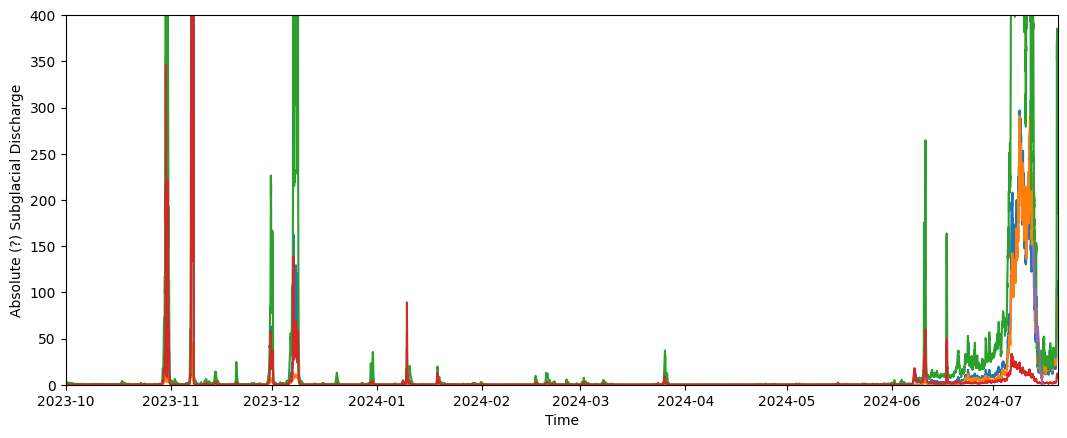

In [11]:
fig = plt.figure(figsize=(2*6.4,4.8))

plt.plot(df_ght.index, model_own_power.slope * np.power(df_ght["mean"], power))
plt.plot(df_ght.index, model_own_power14.slope * np.power(df_ght["mean14"], power))
plt.plot(df_ght.index, model_own_power47.slope * np.power(df_ght["mean47"], power))
plt.plot(df_ght.index, model_own_power710.slope * np.power(df_ght["mean710"], power))
# plt.plot(df_ght.index, (model_own_power.slope - moe_own_power) * np.power(df_ght["mean"], power))
# plt.plot(df_ght.index, (model_own_power.slope + moe_own_power) * np.power(df_ght["mean"], power))
plt.plot(more_trimmed_df_ght.index, more_trimmed_df_ght["discharge"])
plt.ylabel('Absolute (?) Subglacial Discharge')
plt.xlabel('Time')
plt.xlim(np.datetime64('2023-10-01'), np.datetime64('2024-07-20'))
plt.ylim(0, 400)

df_ght.head()

In [12]:
ols_df = pd.concat([trimmed_df_ght["discharge"], np.power(trimmed_df_ght["mean"], power)], axis = 1)

results = smf.ols('discharge ~ mean - 1', ols_df).fit()

ols_df14 = pd.concat([trimmed_df_ght["discharge"], np.power(trimmed_df_ght["mean14"], power14)], axis = 1)

results14 = smf.ols('discharge ~ mean14 - 1', ols_df14).fit()

ols_df47 = pd.concat([trimmed_df_ght["discharge"], np.power(trimmed_df_ght["mean47"], power47)], axis = 1)

results47 = smf.ols('discharge ~ mean47 - 1', ols_df47).fit()

ols_df710 = pd.concat([trimmed_df_ght["discharge"], np.power(trimmed_df_ght["mean710"], power710)], axis = 1)

results710 = smf.ols('discharge ~ mean710 - 1', ols_df710).fit()



C:\Users\Admin\AppData\Local\Temp\ipykernel_113524\39273638.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = results.params[0]
C:\Users\Admin\AppData\Local\Temp\ipykernel_113524\39273638.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  moe = results.bse[0] * 1.96
C:\Users\Admin\AppData\Local\Temp\ipykernel_113524\39273638.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope14 = results14.params[0]
C:\Users\Admin\A

(0.0, 1000.0)

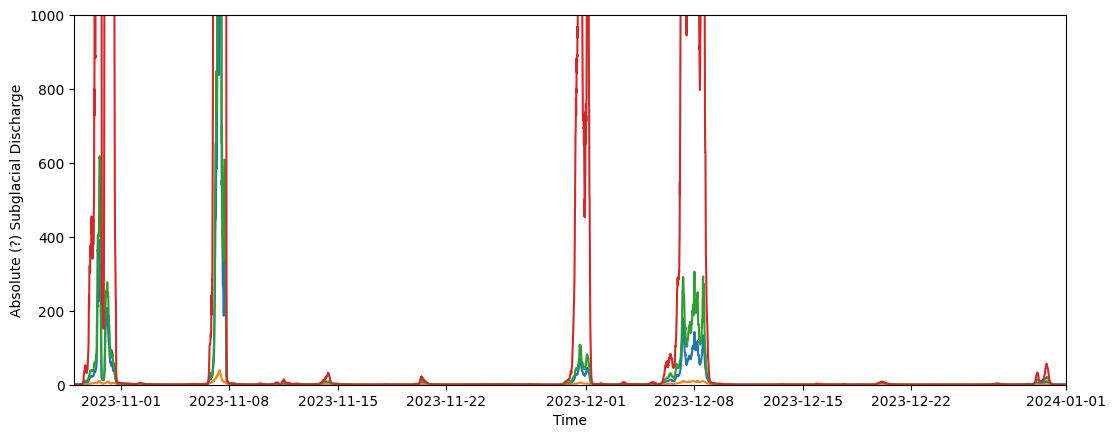

In [13]:
slope = results.params[0]
moe = results.bse[0] * 1.96

slope14 = results14.params[0]
slope47 = results47.params[0]
slope710 = results710.params[0]

fig = plt.figure(figsize=(2*6.4,4.8))

plt.plot(df_ght.index, slope * np.power(df_ght["mean"], power))
plt.plot(df_ght.index, slope14 * np.power(df_ght["mean14"], power14))
plt.plot(df_ght.index, slope47 * np.power(df_ght["mean47"], power47))
plt.plot(df_ght.index, slope710 * np.power(df_ght["mean710"], power710))
# plt.plot(df_ght.index, (slope - moe) * np.power(df_ght["mean"], power))
# plt.plot(df_ght.index, (slope + moe) * np.power(df_ght["mean"], power))
plt.plot(more_trimmed_df_ght.index, more_trimmed_df_ght["discharge"])
plt.ylabel('Absolute (?) Subglacial Discharge')
plt.xlabel('Time')
plt.xlim(np.datetime64('2023-10-29'), np.datetime64('2024-01-01'))
plt.ylim(0, 1000)

(0.0, 800.0)

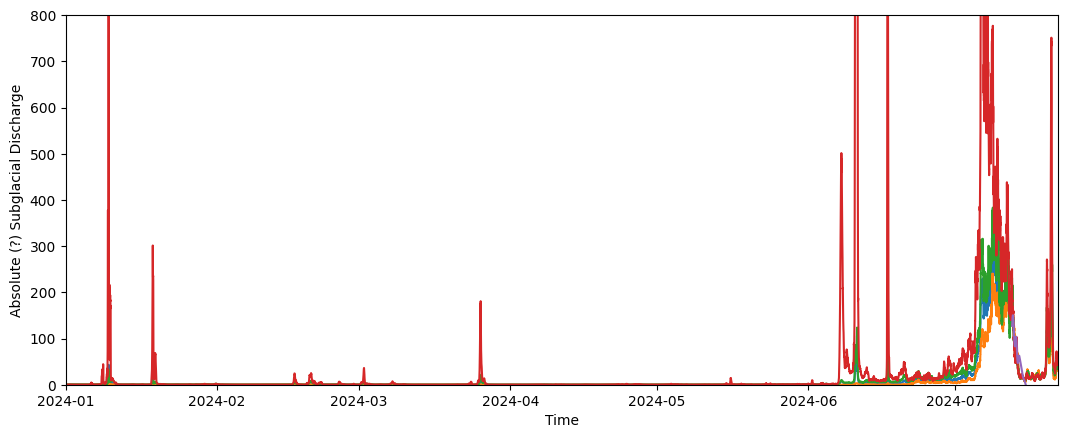

In [16]:
before = df_ght.loc[(df_ght.index <= '2023-10-29 00:00:00'), "mean"]
during = scipy.signal.medfilt(df_ght.loc[(df_ght.index > '2023-10-29 00:00:00') & (df_ght.index < '2024-01-01 00:00:00'), "mean"], 361)
after = df_ght.loc[(df_ght.index >= '2024-01-01 00:00:00'), "mean"]

before14 = df_ght.loc[(df_ght.index <= '2023-10-29 00:00:00'), "mean14"]
during14 = scipy.signal.medfilt(df_ght.loc[(df_ght.index > '2023-10-29 00:00:00') & (df_ght.index < '2024-01-01 00:00:00'), "mean14"], 361)
after14 = df_ght.loc[(df_ght.index >= '2024-01-01 00:00:00'), "mean14"]

before47 = df_ght.loc[(df_ght.index <= '2023-10-29 00:00:00'), "mean47"]
during47 = scipy.signal.medfilt(df_ght.loc[(df_ght.index > '2023-10-29 00:00:00') & (df_ght.index < '2024-01-01 00:00:00'), "mean47"], 361)
after47 = df_ght.loc[(df_ght.index >= '2024-01-01 00:00:00'), "mean47"]

before710 = df_ght.loc[(df_ght.index <= '2023-10-29 00:00:00'), "mean710"]
during710 = scipy.signal.medfilt(df_ght.loc[(df_ght.index > '2023-10-29 00:00:00') & (df_ght.index < '2024-01-01 00:00:00'), "mean710"], 361)
after710 = df_ght.loc[(df_ght.index >= '2024-01-01 00:00:00'), "mean710"]

smoothened = np.concatenate([before, during, after])
smoothened14 = np.concatenate([before14, during14, after14])
smoothened47 = np.concatenate([before47, during47, after47])
smoothened710 = np.concatenate([before710, during710, after710])

fig = plt.figure(figsize=(2*6.4,4.8))

plt.plot(df_ght.index, slope * np.power(smoothened, power))
plt.plot(df_ght.index, slope14 * np.power(smoothened14, power14))
plt.plot(df_ght.index, slope47 * np.power(smoothened47, power47))
plt.plot(df_ght.index, slope710 * np.power(smoothened710, power710))
# plt.plot(df_ght.index, (slope - moe) * np.power(smoothened, power))
# plt.plot(df_ght.index, (slope + moe) * np.power(smoothened, power))
plt.plot(more_trimmed_df_ght.index, more_trimmed_df_ght["discharge"])
plt.ylabel('Absolute (?) Subglacial Discharge')
plt.xlabel('Time')
plt.xlim(np.datetime64('2024-01-01'), np.datetime64('2024-07-22'))
plt.ylim(0, 800)

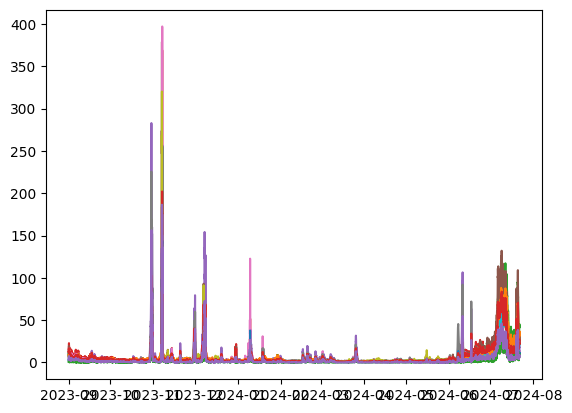

In [48]:
plt.plot(df_ght.index, df_ght[df_ght.columns[:-2]])

